# COMPAS Analysis in Python


In [1]:
# Core libraries used in the lecture instructions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Make output easier to read
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.max_rows", 200)

## 1. Load the dataset


In [2]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

print("Raw dataset shape:", raw_data.shape)
raw_data.head(10)

Raw dataset shape: (7214, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,0,1,0,0,0,0.0,2013-11-30 04:50:18,2013-12-01 12:28:56,13022355MM10A,2013-11-30,NaN,0.0,M,Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-11-30,Risk of Violence,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,0,6,0,0,14,-1.0,2014-02-18 05:08:24,2014-02-24 12:18:30,14002304CF10A,2014-02-18,NaN,1.0,F,Possession Burglary Tools,1,14004485CF10A,(F2),0.0,2014-03-31,Poss of Firearm by Convic Felo,2014-03-31,2014-04-18,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,6,Medium,2014-02-19,Risk of Violence,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,0,4,0,0,3,-1.0,2013-08-29 08:55:23,2013-08-30 08:42:13,13012216CF10A,NaN,2013-08-29,1.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-08-30,Risk of Violence,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,0,1,0,0,0,-1.0,2014-03-15 05:35:34,2014-03-18 04:28:46,14004524MM10A,2014-03-15,NaN,1.0,M,Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2014-03-16,Risk of Violence,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less

## 2. Replicate preprocessing and filtering



In [3]:
# Variables treated as numeric and datetime in the R workflow
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Keep the same columns used in the R notebook
df = raw_data[
    [
        "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
        "priors_count", "days_b_screening_arrest", "decile_score",
        "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
    ]
].copy()

# Apply the same row filters as the R notebook
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"].copy()

# Convert jail dates
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True, errors="coerce")

# Derived variables that mirror the R factors
df["crime_factor"] = pd.Categorical(df["c_charge_degree"], categories=["F", "M"])
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Greater than 45", "Less than 25"]
)
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"]
)
df["gender_factor"] = pd.Categorical(df["sex"], categories=["Male", "Female"])
df["high_score"] = (df["score_text"] != "Low").astype(int)

print("Filtered dataset shape:", df.shape)
df.head()

Filtered dataset shape: (6172, 18)


,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,high_score
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,0
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,0
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,0
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,0
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   object             
 2   race                     6172 non-null   object             
 3   age_cat                  6172 non-null   object             
 4   score_text               6172 non-null   object             
 5   sex                      6172 non-null   object             
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   int64              
 10  two_year_recid           6172 non-null   int64              
 11  c_jail_in                6172 non-n

## 3. Exploratory data analysis

This computes the same derived jail-stay variable, reports the correlation with decile score,
and summarizes the demographic structure of the filtered sample.

In [5]:
# Same length-of-stay calculation used in the R notebook
df["length_of_stay"] = (df["c_jail_out"].dt.normalize() - df["c_jail_in"].dt.normalize()).dt.days

corr_value = df["length_of_stay"].corr(df["decile_score"])
print("Correlation between length_of_stay and decile_score:", round(corr_value, 7))

Correlation between length_of_stay and decile_score: 0.2073297


In [6]:
print("Age category counts")
print(df["age_cat"].value_counts().reindex(["25 - 45", "Greater than 45", "Less than 25"]))

Age category counts
age_cat
25 - 45            3532
Greater than 45    1293
Less than 25       1347
Name: count, dtype: int64


In [7]:
print("Race counts")
print(df["race"].value_counts().reindex(["African-American", "Asian", "Caucasian", "Hispanic", "Native American", "Other"]))

Race counts
race
African-American    3175
Asian                 31
Caucasian           2103
Hispanic             509
Native American       11
Other                343
Name: count, dtype: int64


In [8]:
race_counts = df["race"].value_counts()
total_n = len(df)

print(f"Black defendants: {race_counts['African-American'] / total_n * 100:.2f}%")
print(f"White defendants: {race_counts['Caucasian'] / total_n * 100:.2f}%")
print(f"Hispanic defendants: {race_counts['Hispanic'] / total_n * 100:.2f}%")
print(f"Asian defendants: {race_counts['Asian'] / total_n * 100:.2f}%")
print(f"Native American defendants: {race_counts['Native American'] / total_n * 100:.2f}%")

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [9]:
print("Score text counts")
print(df["score_text"].value_counts().reindex(["High", "Low", "Medium"]))

Score text counts
score_text
High      1144
Low       3421
Medium    1607
Name: count, dtype: int64


In [10]:
sex_race_table = pd.crosstab(df["sex"], df["race"])
print(sex_race_table)

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [11]:
print("Sex counts")
print(df["sex"].value_counts().reindex(["Female", "Male"]))

sex_counts = df["sex"].value_counts()
print(f"Men: {sex_counts['Male'] / total_n * 100:.2f}%")
print(f"Women: {sex_counts['Female'] / total_n * 100:.2f}%")

Sex counts
sex
Female    1175
Male      4997
Name: count, dtype: int64
Men: 80.96%
Women: 19.04%


In [12]:
recid_count = (df["two_year_recid"] == 1).sum()
recid_pct = (df["two_year_recid"] == 1).mean() * 100

print("Number with two-year recidivism =", recid_count)
print(f"Two-year recidivism percentage = {recid_pct:.5f}")

Number with two-year recidivism = 2809
Two-year recidivism percentage = 45.51199


### Decile-score histograms by race

Compares Black and White defendants' decile-score distributions side by side.

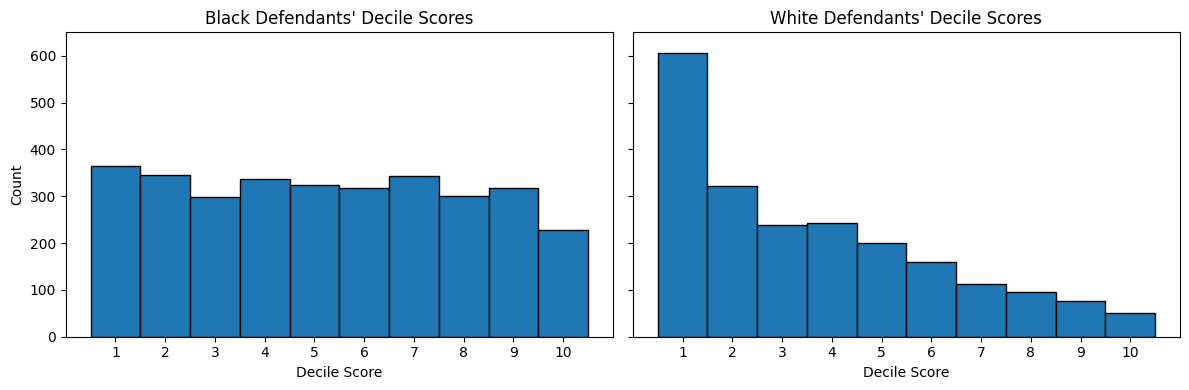

In [13]:
black_scores = df.loc[df["race"] == "African-American", "decile_score"]
white_scores = df.loc[df["race"] == "Caucasian", "decile_score"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(black_scores, bins=np.arange(0.5, 10.6, 1), edgecolor="black")
axes[0].set_title("Black Defendants' Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_xticks(range(1, 11))
axes[0].set_ylim(0, 650)

axes[1].hist(white_scores, bins=np.arange(0.5, 10.6, 1), edgecolor="black")
axes[1].set_title("White Defendants' Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_xticks(range(1, 11))
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

In [14]:
decile_race_table = pd.crosstab(df["decile_score"], df["race"])
decile_race_table

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## 4. Logistic regression model

The R notebook fits a binomial logistic regression where the target is whether the COMPAS score is above Low.
The predictors are: gender, age category, race, prior count, harge degee, two-year recivism

The reference categories are matched to the R script: gender: Male, age: 25 - 45, race: Caucasian, charge degree: F

In [15]:
formula = '''
high_score ~
C(gender_factor, Treatment(reference="Male")) +
C(age_factor, Treatment(reference="25 - 45")) +
C(race_factor, Treatment(reference="Caucasian")) +
priors_count +
C(crime_factor, Treatment(reference="F")) +
two_year_recid
'''

model_glm = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Binomial()
).fit()

print(model_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             high_score   No. Observations:                 6172
Model:                            GLM   Df Residuals:                     6160
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3084.2
Date:                Thu, 26 Mar 2026   Deviance:                       6168.4
Time:                        14:09:09   Pearson chi2:                 6.07e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3128
Covariance Type:            nonrobust                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

### Interpretation of the main coefficients

The original R notebook interprets several effects in odds/probability terms.  
Below ishow the same calculations, but in python.

In [16]:
# Baseline probability from the intercept
control = np.exp(model_glm.params["Intercept"]) / (1 + np.exp(model_glm.params["Intercept"]))
print("Baseline probability from intercept:", control)

# African-American effect relative to Caucasian
race_effect = model_glm.params['C(race_factor, Treatment(reference="Caucasian"))[T.African-American]']
race_adjusted_effect = np.exp(race_effect) / (1 - control + control * np.exp(race_effect))
print("Adjusted multiplicative effect for African-American vs Caucasian:", race_adjusted_effect)

# Female effect relative to Male
gender_effect = model_glm.params['C(gender_factor, Treatment(reference="Male"))[T.Female]']
gender_adjusted_effect = np.exp(gender_effect) / (1 - control + control * np.exp(gender_effect))
print("Adjusted multiplicative effect for Female vs Male:", gender_adjusted_effect)

# Less than 25 effect relative to 25 - 45
young_effect = model_glm.params['C(age_factor, Treatment(reference="25 - 45"))[T.Less than 25]']
young_adjusted_effect = np.exp(young_effect) / (1 - control + control * np.exp(young_effect))
print("Adjusted multiplicative effect for age < 25 vs 25 - 45:", young_adjusted_effect)

Baseline probability from intercept: 0.17864742702528638
Adjusted multiplicative effect for African-American vs Caucasian: 1.4528374133823456
Adjusted multiplicative effect for Female vs Male: 1.1947946538834509
Adjusted multiplicative effect for age < 25 vs 25 - 45: 2.4961195307539574


## 5. Prediction and diagnostics



In [17]:
df["pred_prob"] = model_glm.predict(df)
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")

overall_cm = pd.crosstab(
    pd.Series(df["pred_class"], name="Predicted"),
    pd.Series(df["two_year_recid"], name="Actual")
)

print("Overall confusion matrix")
print(overall_cm)

TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]
n = overall_cm.to_numpy().sum()

print(f"Accuracy  : {(TP + TN) / n:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")

Overall confusion matrix
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864
Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [18]:
race_metrics = (
    df.assign(
        actual=df["two_year_recid"].astype(int),
        pred=(df["pred_class"] == "Recid").astype(int)
    )
    .groupby("race", dropna=False)
    .apply(
        lambda g: pd.Series({
            "n": len(g),
            "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
            "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
            "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
            "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
        })
    )
    .reset_index()
)

race_metrics["Accuracy"] = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"] = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"] = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

race_metrics = race_metrics.sort_values("n", ascending=False).reset_index(drop=True)

print("Confusion matrix by race")
print(race_metrics)

Confusion matrix by race
               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall    FPR    FNR
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827  0.367  0.173
1         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464  0.104  0.536
2          Hispanic   509    81   306   14  108     0.760      0.853   0.429  0.044  0.571
3             Other   343    22   216    3  102     0.694      0.880   0.177  0.014  0.823
4             Asian    31     2    22    1    6     0.774      0.667   0.250  0.043  0.750
5   Native American    11     5     2    4    0     0.636      0.556   1.000  0.667  0.000


/tmp/ipykernel_5499/1676625945.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [19]:
caucasian_fpr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FPR"].iloc[0]
caucasian_fnr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FNR"].iloc[0]

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()
disparity["delta_FPR"] = (disparity["FPR"] - caucasian_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - caucasian_fnr).round(3)

print("FPR and FNR disparity by race relative to Caucasian defendants")
print(disparity)

FPR and FNR disparity by race relative to Caucasian defendants
               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
1         Caucasian  2103  0.104  0.536      0.000      0.000
2          Hispanic   509  0.044  0.571     -0.060      0.035
3             Other   343  0.014  0.823     -0.090      0.287
4             Asian    31  0.043  0.750     -0.061      0.214
5   Native American    11  0.667  0.000      0.563     -0.536


## 6. Interpretation


After filtering, the sample has 6,172 observations and is majority African-American.
Length of stay and decile score have a positive but weak relationship.
The logistic regression shows the same pattern as the R notebook:
African-American defendants have a positive, significant coefficient vs. Caucasian.
Defendants under 25 are much more likely to get higher risk scores.
More priors and actual recidivism increase assigned risk.
Using a 0.5 threshold gives the same type of diagnostic results as in lecture.
The confusion matrix by race shows unequal error rates, highlighting the fairness issue in COMPAS.
Small differences across Python vs. R come from encoding, precision, and formatting, but the overall conclusions are the same.